# Project 2: Exploratory Data Analysis (EDA) Report
**Reem AlShehabi**

---
## Assigned Topic:
**World Development Statistics** from [Gapminder](https://www.gapminder.org/). Three files by country and year: population, life expectancy, and GNI per capita (Atlas method, constant 2021 USD).

## Selected Problem Statement:
**Approach 2: Human Capital Strategy & Philanthropy**

A philanthropic foundation lacks clear historical blueprints to design effective human development programs. The Strategy Director needs to evaluate combined historical trends of population, life expectancy, and GNI to identify countries that successfully transitioned from low-income and low-lifespan to high-income and high-lifespan statuses. Uncovering these proven baselines will allow the foundation to implement evidence-based programs modeled after these successful nations.

## 1. Introduction & Objectives

### 1.1 Context & Background
Since 1960 most countries got richer and lived longer. They did not all do it at the same speed or in the same order. The foundation wants to learn from the countries that actually made the jump from poor and short-lived to rich and long-lived. This report uses Gapminder data on population, GNI per capita, and life expectancy to find those countries and describe how they moved.

### 1.2 Core Analytical Objectives
* See how income and life expectancy changed together from 1960 to 2020.
* Find the countries that went from low-income and low-lifespan to high-income and high-lifespan.
* Look at how far and how fast those countries moved.
* Point to patterns the foundation can apply in its own programs for struggling countries.

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: import modules cleanly with standard aliases, load data with relative paths.)*

In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

%matplotlib inline

In [2]:
# load the three files with relative paths
population  = pd.read_csv("../Data/population.csv")
life_exp    = pd.read_csv("../Data/life_expectancy.csv")
gni_per_cap = pd.read_csv("../Data/gni_per_cap_atlas_method_con2021.csv")

print("population :", population.shape)
print("life_exp   :", life_exp.shape)
print("gni_per_cap:", gni_per_cap.shape)

population : (197, 302)
life_exp   : (195, 302)
gni_per_cap: (191, 252)


---
## 3. Data Handling

The files come in wide shape, one column per year from 1800 to 2100, and the numbers are stored as text like `3.28M`. I reshape each file to long form, turn the text into numbers, merge the three files, keep the years 1960 to 2020, and drop missing rows. The clean table is saved to `data/world_development_clean.csv`.

In [3]:
# check shape, year range, missing names and dtype for each file
for name, d in [("population", population), ("life_expectancy", life_exp), ("gni_per_capita", gni_per_cap)]:
    print(name, d.shape, "| years", d.columns[1], "to", d.columns[-1], "| 2000 dtype:", d["2000"].dtype)

population.head()

population (197, 302) | years 1800 to 2100 | 2000 dtype: str
life_expectancy (195, 302) | years 1800 to 2100 | 2000 dtype: float64
gni_per_capita (191, 252) | years 1800 to 2050 | 2000 dtype: str


,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,Afghanistan,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,...,108M,108M,109M,109M,109M,110M,110M,110M,111M,111M
1,Angola,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,...,125M,126M,127M,128M,129M,130M,131M,131M,132M,133M
2,Albania,400k,402k,404k,405k,407k,409k,411k,413k,414k,...,1.35M,1.32M,1.29M,1.26M,1.23M,1.21M,1.18M,1.15M,1.12M,1.1M
3,Andorra,2650,2650,2650,2650,2650,2650,2650,2650,2650,...,62.5k,62.2k,61.9k,61.7k,61.4k,61.2k,60.9k,60.7k,60.5k,60.2k
4,United Arab Emirates,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,...,13.5M,13.5M,13.6M,13.7M,13.8M,13.8M,13.9M,14M,14M,14.1M


In [4]:
# the row counts differ, so check which countries are missing from each file
pop_c  = set(population["country"])
life_c = set(life_exp["country"])
gni_c  = set(gni_per_cap["country"])

print("countries in all three files:", len(pop_c & life_c & gni_c))
print("missing from life expectancy:", sorted(pop_c - life_c))
print("missing from gni:", sorted(pop_c - gni_c))
print("only in life or gni, not population:", sorted((life_c | gni_c) - pop_c))

countries in all three files: 190
missing from life expectancy: ['Holy See', 'Liechtenstein']
missing from gni: ['Andorra', 'Holy See', 'Monaco', 'North Korea', 'San Marino', 'Taiwan']
only in life or gni, not population: []


In [5]:
# reshape each file from wide to long
def melt_years(d, value_name):
    long = d.melt(id_vars="country", var_name="year", value_name=value_name)
    long["year"] = long["year"].astype(int)
    return long

pop_long  = melt_years(population,  "population")
life_long = melt_years(life_exp,    "life_expectancy")
gni_long  = melt_years(gni_per_cap, "gni_per_capita")

# turn text like 3.28M or 27.2k into a plain number
def parse_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", "")
    mult = 1
    if s and s[-1] in "kKmMbB":
        mult = {"k": 1e3, "m": 1e6, "b": 1e9}[s[-1].lower()]
        s = s[:-1]
    try:
        return float(s) * mult
    except ValueError:
        return np.nan

pop_long["population"]     = pop_long["population"].apply(parse_number)
gni_long["gni_per_capita"] = gni_long["gni_per_capita"].apply(parse_number)
# life expectancy is already numeric

# merge the three files on country and year, inner join drops the countries missing above
df = (pop_long
      .merge(life_long, on=["country", "year"])
      .merge(gni_long,  on=["country", "year"]))

# keep 1960 to 2020, the rest are Gapminder predictions on future years
df = df[(df["year"] >= 1960) & (df["year"] <= 2020)]

# drop rows with missing values
print("missing before drop:")
print(df.isna().sum())
df = df.dropna().reset_index(drop=True)

# the low life expectancy values left here are real crises (Rwanda 1994, Cambodia 1977 to 1979), not errors
# add a decade column
df["decade"] = (df["year"] // 10) * 10
df = df[["country", "year", "decade", "population", "life_expectancy", "gni_per_capita"]]

df.to_csv("../Data/world_development_clean.csv", index=False)
print("clean shape:", df.shape, "| countries:", df["country"].nunique())
df.head()

missing before drop:
country            0
year               0
population         0
life_expectancy    6
gni_per_capita     0
dtype: int64
clean shape: (11584, 6) | countries: 190


,country,year,decade,population,life_expectancy,gni_per_capita
0,Afghanistan,1960,1960,8620000.0,45.0,469.0
1,Angola,1960,1960,5360000.0,46.3,1720.0
2,Albania,1960,1960,1710000.0,62.5,736.0
3,United Arab Emirates,1960,1960,133000.0,60.3,27200.0
4,Argentina,1960,1960,20300000.0,65.3,4740.0


### 3.1 Checking the low life expectancy values

mean 65.3, median 67.3, skew -0.56


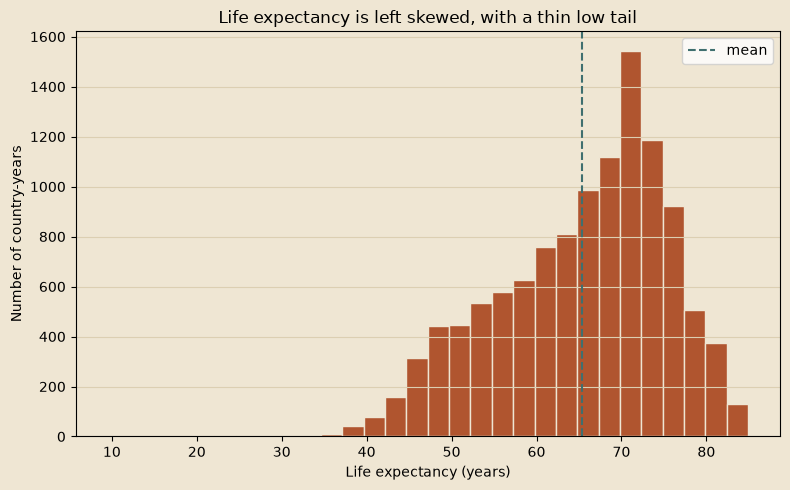

In [6]:
#life expectancy is left skewed
#colors were chosen with Ai assistance 
#the plot was saved to be added to the presentation
print("mean %.1f, median %.1f, skew %.2f" % (
    df["life_expectancy"].mean(), df["life_expectancy"].median(), df["life_expectancy"].skew()))

plt.figure(figsize=(8, 5), facecolor="#EFE6D3")
plt.hist(df["life_expectancy"], bins=30, color="#B0552F", edgecolor="#EFE6D3")
plt.axvline(df["life_expectancy"].mean(), color="#3F6F6F", linestyle="--", label="mean")
plt.xlabel("Life expectancy (years)")
plt.ylabel("Number of country-years")
plt.title("Life expectancy is left skewed, with a thin low tail")
plt.gca().set_facecolor("#EFE6D3")
plt.grid(color="#DCCFB2", axis="y")
plt.legend()
plt.tight_layout()
plt.savefig("../images/life_expectancy_distribution.png", dpi=150, facecolor="#EFE6D3")
plt.show()

In [7]:
# the country-years with the lowest life expectancy
df.sort_values("life_expectancy").head(6)[["country", "year", "life_expectancy"]]

,country,year,life_expectancy
6605,Rwanda,1994,9.5
2290,Burundi,1972,17.1
3700,Cambodia,1979,24.1
3510,Cambodia,1978,24.2
3320,Cambodia,1977,24.4
3130,Cambodia,1976,24.5


**Are the low values real?**
> Life expectancy is left skewed, skew -0.56, and the mean 65.3 sits below the median 67.3 because the low tail pulls it down. Most country-years fall between 50 and 80. The lowest points are not errors. They match documented events: the Rwandan genocide in 1994, life expectancy near 9.5 years [6], and the Khmer Rouge period in Cambodia from 1975 to 1979, near 24 years [7]. We keep them because they are real history.

---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: descriptive statistics, sorting, and Boolean masking.)*

### 4.1. Summary statistics

In [8]:
# summary of the three measures
df[["population", "life_expectancy", "gni_per_capita"]].describe().round(1)

,population,life_expectancy,gni_per_capita
count,1.158400e+04,11584.0,11584.0
mean,2.783858e+07,65.3,9055.5
std,1.097919e+08,10.0,14868.3
min,4.580000e+03,9.5,67.0
25%,1.340000e+06,58.4,988.8
50%,5.300000e+06,67.3,2820.0
75%,1.630000e+07,72.8,8762.5
max,1.420000e+09,84.9,117000.0


In [9]:
# mean life expectancy and income by decade
df.groupby("decade")[["life_expectancy", "gni_per_capita"]].mean().round(1)

,life_expectancy,gni_per_capita
decade,,
1960,58.3,4726.9
1970,61.7,6960.8
1980,64.8,7521.6
1990,66.4,9060.5
2000,68.5,11384.7
2010,71.6,14298.4
2020,72.4,12981.2


### 4.2. Finding the transition countries

In [10]:
# take a 1960 and a 2020 snapshot of every country
start = df[df["year"] == 1960].set_index("country")
end   = df[df["year"] == 2020].set_index("country")
snap  = start.join(end, lsuffix="_1960", rsuffix="_2020").dropna()

# income growth and life expectancy gain per country
snap["gni_mult"]  = snap["gni_per_capita_2020"] / snap["gni_per_capita_1960"]
snap["life_gain"] = snap["life_expectancy_2020"] - snap["life_expectancy_1960"]
print("countries with both years:", len(snap))

# how strongly income and life expectancy move together (correlation) 
corr_1960 = np.corrcoef(np.log10(start["gni_per_capita"]), start["life_expectancy"])[0, 1]
corr_2020 = np.corrcoef(np.log10(end["gni_per_capita"]), end["life_expectancy"])[0, 1]
print("correlation of log income and life expectancy, 1960:", round(corr_1960, 2))
print("correlation of log income and life expectancy, 2020:", round(corr_2020, 2))

countries with both years: 184
correlation of log income and life expectancy, 1960: 0.7
correlation of log income and life expectancy, 2020: 0.82


In [11]:
# started poor and short-lived in 1960, rich and long-lived by 2020
low_start = (snap["gni_per_capita_1960"] < 2000) & (snap["life_expectancy_1960"] < 60)
high_end  = (snap["gni_per_capita_2020"] >= 10000) & (snap["life_expectancy_2020"] >= 72)

transition = snap[low_start & high_end]
transition[["life_expectancy_1960", "gni_per_capita_1960",
            "life_expectancy_2020", "gni_per_capita_2020",
            "gni_mult", "life_gain"]].sort_values("gni_mult", ascending=False).round(1)

,life_expectancy_1960,gni_per_capita_1960,life_expectancy_2020,gni_per_capita_2020,gni_mult,life_gain
country,,,,,,
South Korea,59.1,1290.0,82.8,33000.0,25.6,23.7
China,27.8,454.0,77.7,10600.0,23.3,49.9
Oman,45.1,611.0,72.7,14000.0,22.9,27.6


In [12]:
# biggest life expectancy gains among countries that started poor
poor = snap[snap["gni_per_capita_1960"] < 2000]
poor.sort_values("life_gain", ascending=False).head(8)[
    ["life_expectancy_1960", "life_expectancy_2020", "life_gain"]].round(1)

,life_expectancy_1960,life_expectancy_2020,life_gain
country,,,
China,27.8,77.7,49.9
Maldives,37.8,79.1,41.3
Cameroon,27.5,63.5,36.0
Yemen,36.5,67.8,31.3
Bhutan,42.2,73.3,31.1
Bangladesh,43.8,74.7,30.9
Myanmar,38.7,69.4,30.7
Ethiopia,38.4,69.0,30.6


### 4.3. Visualizations

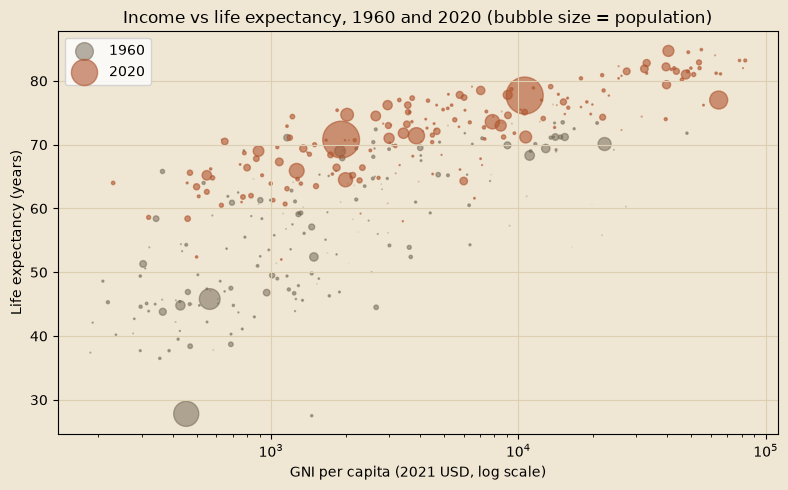

In [13]:
# income against life expectancy, 1960 and 2020, bubble size is population
#i saved the plot to be added to the presentation
plt.figure(figsize=(8, 5), facecolor="#EFE6D3")
plt.scatter(start["gni_per_capita"], start["life_expectancy"], s=start["population"]/2e6, color="#6E6250", alpha=0.5, label="1960")
plt.scatter(end["gni_per_capita"], end["life_expectancy"], s=end["population"]/2e6, color="#B0552F", alpha=0.6, label="2020")
plt.xscale("log")
plt.xlabel("GNI per capita (2021 USD, log scale)")
plt.ylabel("Life expectancy (years)")
plt.title("Income vs life expectancy, 1960 and 2020 (bubble size = population)")
plt.gca().set_facecolor("#EFE6D3")
plt.grid(color="#DCCFB2")
plt.legend()
plt.tight_layout()
plt.savefig("../images/fig1_income_vs_life.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Visualization 1 Interpretation:**
> GNI is on a log scale because income runs from a few hundred dollars to over 100,000. On a normal axis the poorer countries would bunch up on the left, so the log scale spreads them out and makes the pattern clear. The 1960 points sit low and to the left. The 2020 points sit higher and to the right. Almost every country gained both income and years of life. Bubble size is population, so the big bubbles are large countries like China and India, and both small and large countries made the shift. Income and life expectancy still move together in 2020, the correlation is 0.82.

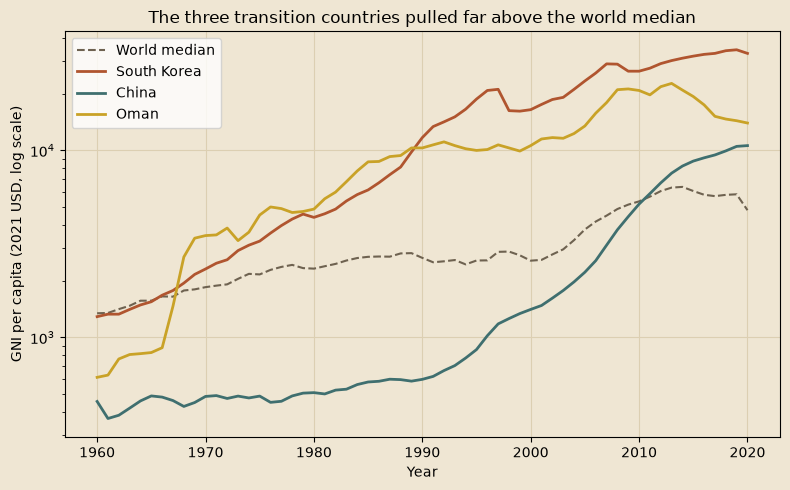

In [14]:
# income path of the three transition countries against the world median
plt.figure(figsize=(8, 5), facecolor="#EFE6D3")
world_med = df.groupby("year")["gni_per_capita"].median()
plt.plot(world_med.index, world_med.values, color="#6E6250", linestyle="--", label="World median")
for country, colour in [("South Korea", "#B0552F"), ("China", "#3F6F6F"), ("Oman", "#C9A227")]:
    d = df[df["country"] == country]
    plt.plot(d["year"], d["gni_per_capita"], color=colour, linewidth=2, label=country)
plt.yscale("log")
plt.xlabel("Year")
plt.ylabel("GNI per capita (2021 USD, log scale)")
plt.title("The three transition countries pulled far above the world median")
plt.gca().set_facecolor("#EFE6D3")
plt.grid(color="#DCCFB2")
plt.legend()
plt.tight_layout()
plt.savefig("../images/fig2_trajectories.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Visualization 2 Interpretation:**
> South Korea, China and Oman all started near or below the world median income in 1960. By 2020 they were far above it. Income grew 25.6 times in South Korea, 23.3 times in China and 22.9 times in Oman. 


**When did each country take off?**
> The three did not rise at the same time, and each had a different trigger. Oman jumped fast around 1970, from 829 to 3500 in five years, a surge driven by oil. South Korea climbed steadily from the 1960s and crossed 10,000 around 1990 through export industry and education. China stayed flat near 500 until about 1980, then grew explosively in the 2000s, with its fastest jump near 2010, after its market reforms. So a takeoff can begin in any decade.

**Tips for the foundation, development programs:**
> * There is no single timeline. A takeoff can start in any decade with the right trigger, so it is never too late for a country.
> * Oil money worked fast for Oman but was volatile. Its income fell after 2010 when oil prices dropped, so resource-rich countries need help to diversify.
> * The steady Korea model, investing in industry and education, was slower but more durable and kept rising. This is the safest path to copy.
> * Big reforms can unlock fast catch-up, as in China, even after decades of no growth. Support policy reform and openness.

### 4.4. Stretch: population growth

In [15]:
# a real birth rate needs a count of births, which these files do not have
# what we can measure from the population file is the yearly population growth rate
df["pop_growth"] = df.groupby("country")["population"].pct_change() * 100

# in 2020, compare each country's population growth to its income
growth_2020 = df[df["year"] == 2020].dropna(subset=["pop_growth"])
corr_growth = np.corrcoef(np.log10(growth_2020["gni_per_capita"]), growth_2020["pop_growth"])[0, 1]
print("correlation of log income and population growth, 2020:", round(corr_growth, 2))

# save the clean file again, now with the growth column
df.to_csv("../Data/world_development_clean.csv", index=False)

correlation of log income and population growth, 2020: -0.62


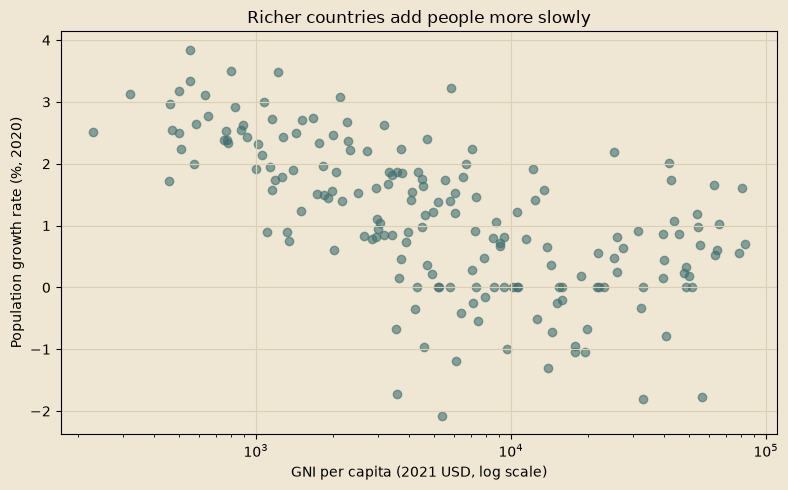

In [16]:
# richer countries add people more slowly
plt.figure(figsize=(8, 5), facecolor="#EFE6D3")
plt.scatter(growth_2020["gni_per_capita"], growth_2020["pop_growth"], color="#3F6F6F", alpha=0.6)
plt.xscale("log")
plt.xlabel("GNI per capita (2021 USD, log scale)")
plt.ylabel("Population growth rate (%, 2020)")
plt.title("Richer countries add people more slowly")
plt.gca().set_facecolor("#EFE6D3")
plt.grid(color="#DCCFB2")
plt.tight_layout()
plt.savefig("../images/fig3_pop_growth.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Stretch interpretation:**
> A true birth rate is not in the data, but population growth rate is. Population growth falls as income rises, the correlation is -0.62. The transition countries show the same pattern over time. South Korea and China both dropped from over 2% growth in the 1960s to about 0% by 2020. So their rise in income and life expectancy came together with a slowdown in population growth.

### 4.5. Stretch: real birth data (children per woman)

In [17]:
# a fourth Gapminder information: children per woman (total fertility rate)
#  based on UN World Population Prospects 2024
fertility  = pd.read_csv("../Data/children_per_woman.csv")
fert_long  = melt_years(fertility, "fertility")

# add fertility to the data 
dff = df.merge(fert_long, on=["country", "year"])
print("rows with fertility:", len(dff), ", countries:", dff["country"].nunique())

# fertility against life expectancy in 2020
f2020 = dff[dff["year"] == 2020]
corr_fert = np.corrcoef(f2020["fertility"], f2020["life_expectancy"])[0, 1]
print("correlation of fertility and life expectancy, 2020:", round(corr_fert, 2))

rows with fertility: 11102 , countries: 182
correlation of fertility and life expectancy, 2020: -0.77


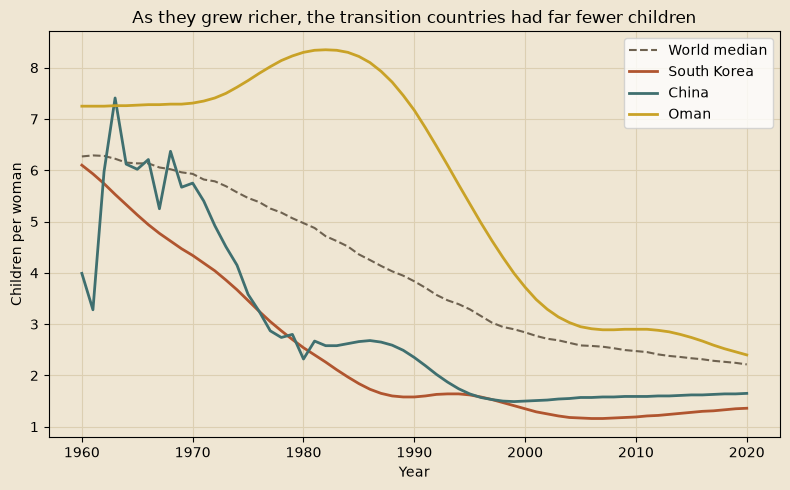

In [18]:
# fertility of the three transition countries against the world median
plt.figure(figsize=(8, 5), facecolor="#EFE6D3")
world_fert = dff.groupby("year")["fertility"].median()
plt.plot(world_fert.index, world_fert.values, color="#6E6250", linestyle="--", label="World median")
for country, colour in [("South Korea", "#B0552F"), ("China", "#3F6F6F"), ("Oman", "#C9A227")]:
    d = dff[dff["country"] == country]
    plt.plot(d["year"], d["fertility"], color=colour, linewidth=2, label=country)
plt.xlabel("Year")
plt.ylabel("Children per woman")
plt.title("As they grew richer, the transition countries had far fewer children")
plt.gca().set_facecolor("#EFE6D3")
plt.grid(color="#DCCFB2")
plt.legend()
plt.tight_layout()
plt.savefig("../images/fig4_fertility.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Stretch interpretation:**
> This is the real birth data, children per woman, from Gapminder. It falls hard as countries develop. Babies per woman dropped from 6.10 to 1.36 in South Korea, 3.99 to 1.65 in China, and 7.25 to 2.40 in Oman. The world median fell from 6.27 to 2.21. Fertility and life expectancy move in opposite directions, the correlation is -0.77. This is the direct cause of the slower population growth we saw earlier.

correlation of fertility and log income, 2020: -0.76


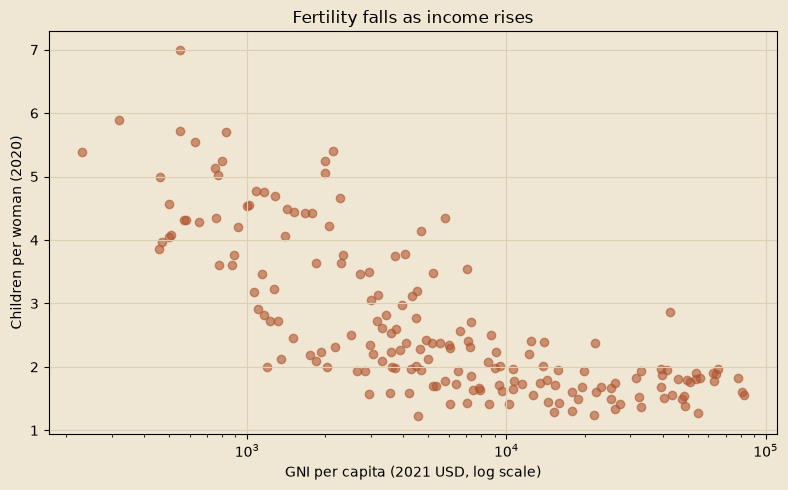

In [19]:
# comparing the birth data with income
corr_fert_gni = np.corrcoef(f2020["fertility"], np.log10(f2020["gni_per_capita"]))[0, 1]
print("correlation of fertility and log income, 2020:", round(corr_fert_gni, 2))

plt.figure(figsize=(8, 5), facecolor="#EFE6D3")
plt.scatter(f2020["gni_per_capita"], f2020["fertility"], color="#B0552F", alpha=0.6)
plt.xscale("log")
plt.xlabel("GNI per capita (2021 USD, log scale)")
plt.ylabel("Children per woman (2020)")
plt.title("Fertility falls as income rises")
plt.gca().set_facecolor("#EFE6D3")
plt.grid(color="#DCCFB2")
plt.tight_layout()
plt.savefig("../images/fig5_fertility_vs_income.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Is this what we expect?**
> Yes. Demographic transition theory says fertility falls as countries get richer and healthier, and that is what we see. Fertility drops as income rises, correlation -0.76, almost as strong as the -0.77 link with life expectancy. So the birth data lines up with both income and life expectancy.

                1960  2020
Developed       3.80  1.74
Underdeveloped  6.64  4.10


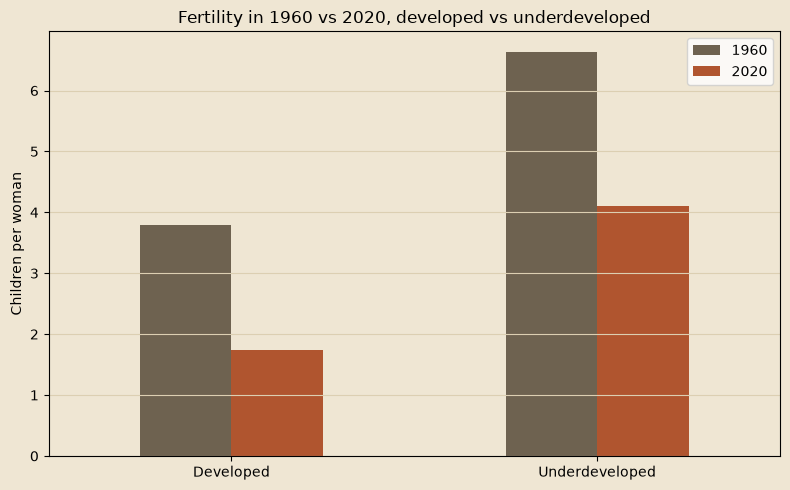

In [20]:
# compare two generations, 1960 and 2020, for developed and underdeveloped countries
# groups by income in 2020
developed      = f2020[f2020["gni_per_capita"] >= 12000]["country"]
underdeveloped = f2020[f2020["gni_per_capita"] <  2000]["country"]

def mean_fertility(countries, year):
    return dff[(dff["country"].isin(countries)) & (dff["year"] == year)]["fertility"].mean()

generations = pd.DataFrame({
    "1960": [mean_fertility(developed, 1960), mean_fertility(underdeveloped, 1960)],
    "2020": [mean_fertility(developed, 2020), mean_fertility(underdeveloped, 2020)],
}, index=["Developed", "Underdeveloped"]).round(2)
print(generations)

ax = generations.plot(kind="bar", figsize=(8, 5), color=["#6E6250", "#B0552F"])
ax.figure.set_facecolor("#EFE6D3")
ax.set_facecolor("#EFE6D3")
plt.ylabel("Children per woman")
plt.title("Fertility in 1960 vs 2020, developed vs underdeveloped")
plt.xticks(rotation=0)
plt.grid(color="#DCCFB2", axis="y")
plt.tight_layout()
plt.savefig("../images/fig6_generations.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Two generations, developed vs underdeveloped:**
> Developed countries (high income in 2020) were already lower in 1960 at 3.80 children per woman, and by 2020 they fell below replacement to 1.74. Underdeveloped countries (low income in 2020) started much higher at 6.64 and are still high at 4.10. Both groups fell, which is expected, but the poorer countries are earlier in the transition. That is where the next big fertility drops are likely to come.

### 4.6. Developed vs underdeveloped: income and life expectancy

In [21]:
#comparing income and life expectancy across the two generations
d2020 = df[df["year"] == 2020]
dev = d2020[d2020["gni_per_capita"] >= 12000]["country"]
und = d2020[d2020["gni_per_capita"] <  2000]["country"]
print("developed:", len(dev), ", underdeveloped:", len(und))

def grp_mean(countries, year, col):
    return df[(df["country"].isin(countries)) & (df["year"] == year)][col].mean()

compare = pd.DataFrame({
    "life 1960": [grp_mean(dev, 1960, "life_expectancy"), grp_mean(und, 1960, "life_expectancy")],
    "life 2020": [grp_mean(dev, 2020, "life_expectancy"), grp_mean(und, 2020, "life_expectancy")],
    "gni 1960":  [grp_mean(dev, 1960, "gni_per_capita"),  grp_mean(und, 1960, "gni_per_capita")],
    "gni 2020":  [grp_mean(dev, 2020, "gni_per_capita"),  grp_mean(und, 2020, "gni_per_capita")],
}, index=["Developed", "Underdeveloped"]).round(1)
compare

developed: 54 , underdeveloped: 48


,life 1960,life 2020,gni 1960,gni 2020
Developed,67.1,79.2,9277.5,35309.3
Underdeveloped,46.1,65.5,683.8,1027.6


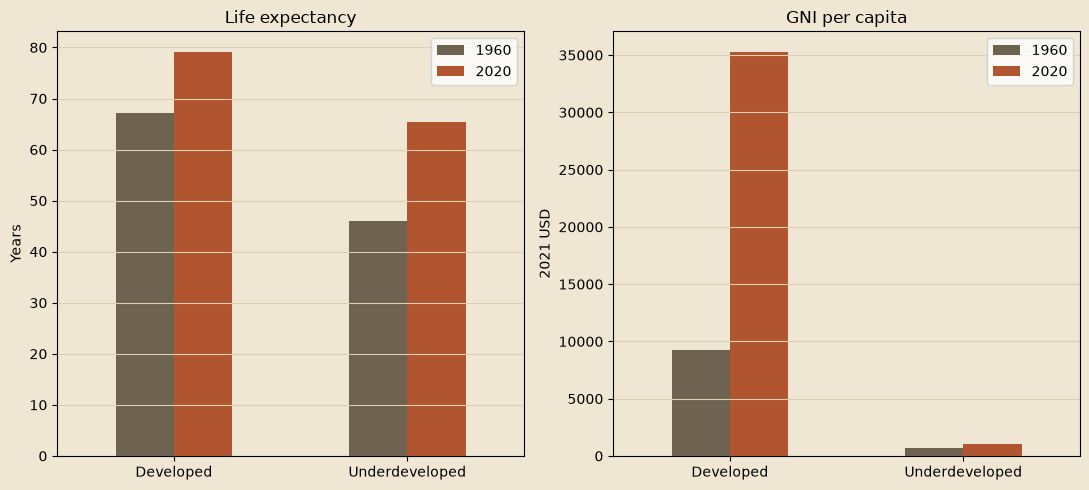

In [22]:
# life expectancy and income side by side, two generations (to use pic in presentation )
fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor="#EFE6D3")

life_tab = compare[["life 1960", "life 2020"]]
life_tab.columns = ["1960", "2020"]
life_tab.plot(kind="bar", ax=axes[0], color=["#6E6250", "#B0552F"])
axes[0].set_title("Life expectancy")
axes[0].set_ylabel("Years")

gni_tab = compare[["gni 1960", "gni 2020"]]
gni_tab.columns = ["1960", "2020"]
gni_tab.plot(kind="bar", ax=axes[1], color=["#6E6250", "#B0552F"])
axes[1].set_title("GNI per capita")
axes[1].set_ylabel("2021 USD")

for ax in axes:
    ax.set_facecolor("#EFE6D3")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(color="#DCCFB2", axis="y")
plt.tight_layout()
plt.savefig("../images/fig7_dev_vs_underdev.png", dpi=150, facecolor="#EFE6D3")
plt.show()

**Developed vs underdeveloped:**
> Both groups improved, but not in the same way. Life expectancy converged: the underdeveloped group gained 19.4 years, from 46.1 to 65.5, while the developed group gained 12.1, from 67.1 to 79.2, so the health gap narrowed. Income diverged: the developed group went from 9278 to 35309, while the underdeveloped group barely moved, from 684 to 1028, so the wealth gap grew. Health reached almost everyone, but income only pulled ahead where countries built industry and skills.

---
## 5. Summary of Findings & Actionable Recommendations

### 5.1 Why this development happened
The data shows what happened. Research explains why.

**Why incomes rose.** The countries that broke through, like South Korea, grew through export-led industrialization and heavy investment in education and skills. The World Bank calls this the East Asian Miracle: stable economic policy, an export push, and large investment in human capital [1]. China grew fast after its market reforms from 1978, and Oman used oil income to build schools, hospitals and roads.

**Why people lived longer.** Life expectancy rose mostly through public health, not medicine alone. Clean water, sanitation, better food, vaccines and antibiotics cut deaths from infectious disease [2]. These reached poor countries too, which is why the underdeveloped group gained 19.4 years of life even without much income growth.

**Why families had fewer children.** As child mortality fell and girls got more schooling, families chose to have fewer children. This is the demographic transition, first set out by Notestein in 1945 [3]. Caldwell links the fast fertility decline in developing countries to government programs and mass education [4], and women with more schooling and more control over their choices have smaller families [5].

Together these explain the pattern in the data. Health mostly improved , income pulled ahead only where countries built industry and skills, and fertility fell as both health and education improved.

### 5.2 Key Insights
* Income and life expectancy rose together across almost every country from 1960 to 2020.
* The full jump from low income and short life to high income and long life was rare. Only 3 countries did it: South Korea, China and Oman.
* Those three grew income more than 22 times, while the world median income went from 1345 to 4785.
* Big life expectancy gains were more common than big income gains. China gained 49.9 years, Maldives 41.3, Yemen 31.3.
* Income and life expectancy are still linked in 2020, correlation 0.82, up from 0.70 in 1960.
* Population growth slows as countries develop, correlation -0.62. The transition countries fell from about 2% growth to near 0%.
* Fertility fell as countries developed, for example South Korea from 6.10 to 1.36 children per woman, and it moves opposite to life expectancy, correlation -0.77.

### 5.3 Actionable Recommendations
* Study South Korea, China and Oman as working models, not just their end results.
* Fund health first. Several poor countries added more than 30 years of life before getting rich.
* Track income and life expectancy together, since a country can gain years of life without much income growth.
* Watch countries that already show rising life expectancy but low income. They may be part way through the transition.
* Support family planning and girls education. In the countries that developed, children per woman fell from about 6 to under 2.
* Focus on the underdeveloped group, still near 4 children per woman in 2020. That is where the transition has the most room left.

### 5.4 Limitations 
* Older years mix records with Gapminder estimates, so early values are less certain.
* Country names and borders changed over 60 years, so 7 countries dropped out of the merge.
* GNI per capita is a mean and hides inequality inside a country.
* It would be beneficial to add education or health spending to explain why these countries moved, more features would give a clearer pattern to answer how exactly the transition happened.

## 6. Data Dictionary & References

### Data Sources
* Gapminder Foundation, World Development data: population, life expectancy, GNI per capita. https://www.gapminder.org
* World Bank, GNI per capita, Atlas method, the source behind the Gapminder income file.
* Gapminder Foundation, Children per woman (total fertility rate), based on UN World Population Prospects 2024. https://www.gapminder.org/data/documentation/gd008/

### 6.3 References
[1] World Bank, *The East Asian Miracle: Economic Growth and Public Policy*. New York, NY, USA: Oxford Univ. Press, 1993.

[2] M. Roser, E. Ortiz-Ospina, and H. Ritchie, "Life expectancy," *Our World in Data*, 2023. [Online]. Available: https://ourworldindata.org/life-expectancy

[3] F. W. Notestein, "Population: the long view," in *Food for the World*, T. W. Schultz, Ed. Chicago, IL, USA: Univ. of Chicago Press, 1945.

[4] J. C. Caldwell, "Toward a restatement of demographic transition theory," *Population and Development Review*, vol. 2, no. 3, pp. 321-366, 1976.

[5] O. Galor, "The demographic transition: causes and consequences," *Cliometrica*, vol. 6, no. 1, pp. 1-28, 2012.

[6] United States Holocaust Memorial Museum, "Reflections on Rwanda and Cambodia." [Online]. Available: https://www.ushmm.org/genocide-prevention/blog/reflections-on-rwanda-and-cambodia

[7] "Cambodian genocide," *Encyclopaedia Britannica*. [Online]. Available: https://www.britannica.com/event/Cambodian-genocide